In [1]:
import os
import numpy as np, pandas as pd, xarray as xr

In [52]:
def interpolate_temperature(temp_row, depth, target_depths):
    mask = np.isfinite(temp_row) & np.isfinite(depth)
    if mask.sum() < 2:
        return np.full(len(target_depths), np.nan)
    d, t = depth[mask], temp_row[mask]
    order = np.argsort(d)
    d, t = d[order], t[order]
    # Interpolate temperature at the target depths
    result = np.full(len(target_depths), np.nan)
    valid = (target_depths >= d.min()) & (target_depths <= d.max())
    result[valid] = np.interp(target_depths[valid], d, t)
    return result

In [63]:
sim_output_folder = r"Calibration\3_MonthBest\dflowfm\output"
his_path = os.path.join(sim_output_folder, "FlowFM_his.nc")
map_path = os.path.join(sim_output_folder,"FlowFM_map.nc")
station_name = "Profiler"
# Depths below surface
target_depths = [2, 10, 30, 50]
# surface_elevation = 25.41
ds_his = xr.open_dataset(his_path)
ds_map = xr.open_dataset(map_path)
station_names = [
    name.decode('utf-8').strip() if isinstance(name, bytes) else str(name).strip()
    for name in ds_his['station_name'].values
]
station_idx = station_names.index(station_name)
# Surface elevation
surface_elevation = ds_his['waterlevel'].values[station_idx][0]
depths_selected = [5, 10, 30, 40, 50]

In [64]:
# Find Profiler coordinates
sx = float(
    ds_his["station_x_coordinate"].isel(
        stations=station_idx
    ).values
)
sy = float(
    ds_his["station_y_coordinate"].isel(
        stations=station_idx
    ).values
)
print("Profiler index:", station_idx)
print("X:", sx)
print("Y:", sy)

Profiler index: 0
X: 60671.11122759
Y: 6956148.90686053


In [65]:
# Find nearest mesh face
temp_map = ds_map["mesh2d_tem1"]
fx = temp_map["mesh2d_face_x"].values
fy = temp_map["mesh2d_face_y"].values
dist_sq = (fx - sx) ** 2 + (fy - sy) ** 2
mesh_idx = np.argmin(dist_sq)
print("Nearest mesh face:", mesh_idx)
print("Distance:", np.sqrt(dist_sq[mesh_idx]))

Nearest mesh face: 950
Distance: 38.90248454582659


In [66]:
# Dữ liệu từ HIS
times_his = pd.to_datetime(ds_his["time"].values)
temp_his_arr = ds_his["temperature"].isel(stations=station_idx).values  # (time, laydim)
z_his_arr = ds_his["zcoordinate_c"].isel(stations=station_idx).values   # (time, laydim)
wl_his_arr = ds_his["waterlevel"].isel(stations=station_idx).values     # (time,)

In [73]:
# Dữ liệu từ MAP
temp_map_face = temp_map.isel(mesh2d_nFaces=mesh_idx)
times_map = pd.to_datetime(ds_map["time"].values)
temp_map_arr = temp_map_face.values                                    # (time, nLayers)
z_map_arr = ds_map["mesh2d_layer_z"].values                            # (nLayers,)

In [76]:
def interpolate_profile(temp_row, z_row, wl, depths):
    """
    Nội suy nhiệt độ tại các độ sâu mục tiêu dưới mặt nước:
    Cao trình đích = Mực nước(t) - Độ sâu
    """
    target_elevations = wl - np.asarray(depths)
    # Lọc bỏ giá trị NaN
    mask = np.isfinite(temp_row) & np.isfinite(z_row)
    if mask.sum() < 2:
        return np.full(len(depths), np.nan), target_elevations
    z_valid = z_row[mask]
    t_valid = temp_row[mask]
    # Sắp xếp tọa độ z tăng dần
    order = np.argsort(z_valid)
    z_sorted = z_valid[order]
    t_sorted = t_valid[order]
    # Nội suy tuyến tính
    interp_temp = np.full(len(depths), np.nan)
    valid_range = (target_elevations >= z_sorted.min()) & (target_elevations <= z_sorted.max())
    interp_temp[valid_range] = np.interp(target_elevations[valid_range], z_sorted, t_sorted)
    return interp_temp, target_elevations

In [77]:
rows_his = []
for i, t in enumerate(times_his):
    temps, elevs = interpolate_profile(temp_his_arr[i, :], z_his_arr[i, :], wl_his_arr[i], target_depths)
    for d, temp, elev in zip(target_depths, temps, elevs):
        rows_his.append({
            "time": t,
            "target_depth": d,
            "depth_elevation": elev,
            "temperature_his": temp
        })
df_his = pd.DataFrame(rows_his)

In [79]:
rows_map = []
for i, t in enumerate(times_map):
    # Lấy mực nước tương ứng từ HIS (hoặc từ MAP nếu có) để đồng nhất cao trình
    wl = wl_his_arr[i] if i < len(wl_his_arr) else wl_his_arr[-1]
    temps, elevs = interpolate_profile(temp_map_arr[i, :], z_map_arr, wl, target_depths)
    for d, temp, elev in zip(target_depths, temps, elevs):
        rows_map.append({
            "time": t,
            "target_depth": d,
            "temperature_map": temp
        })
df_map = pd.DataFrame(rows_map)

In [81]:
df_compare = pd.merge(df_his, df_map, on=["time", "target_depth"], how="inner")
df_compare["difference"] = df_compare["temperature_map"] - df_compare["temperature_his"]
df_compare["absolute_difference"] = df_compare["difference"].abs()
df_compare = df_compare.sort_values(["target_depth", "time"]).reset_index(drop=True)

In [82]:
df_compare

,time,target_depth,depth_elevation,temperature_his,temperature_map,difference,absolute_difference
0,2024-03-26 10:40:00,2,23.410000,3.000000,3.000000,0.000000,0.000000
1,2024-03-27 10:40:00,2,23.409903,1.154647,1.164855,0.010208,0.010208
2,2024-03-28 10:40:00,2,23.409765,2.051712,2.082237,0.030525,0.030525
3,2024-03-29 10:40:00,2,23.409973,2.883692,2.930996,0.047304,0.047304
4,2024-03-30 10:40:00,2,23.410043,2.697529,2.647611,-0.049919,0.049919
...,...,...,...,...,...,...,...
331,2024-06-13 10:40:00,50,-24.590015,4.017532,4.022064,0.004532,0.004532
332,2024-06-14 10:40:00,50,-24.589984,4.011562,4.010479,-0.001083,0.001083
333,2024-06-15 10:40:00,50,-24.590056,4.017680,4.021830,0.004150,0.004150
334,2024-06-16 10:40:00,50,-24.590030,4.022280,4.024574,0.002294,0.002294


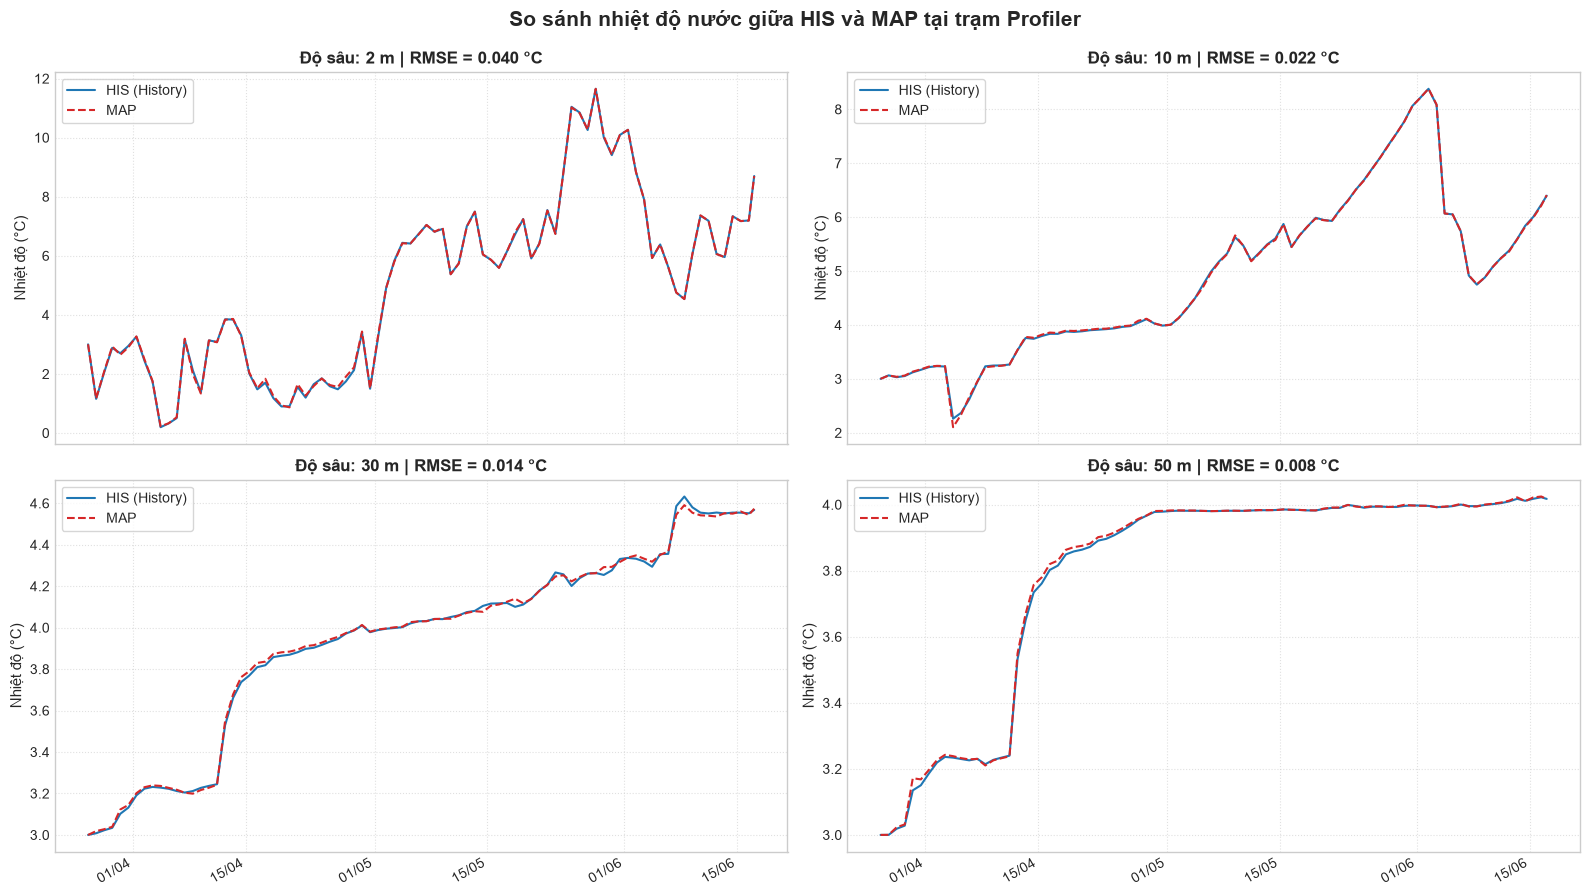

In [83]:
import math
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

# Thiết lập style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.size"] = 10

unique_depths = sorted(df_compare["target_depth"].unique())
n_depths = len(unique_depths)
n_cols = 2
n_rows = math.ceil(n_depths / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows), sharex=True)
axes = np.array(axes).reshape(-1)  # Đưa về mảng 1D để dễ lặp

for idx, depth in enumerate(unique_depths):
    ax = axes[idx]
    df_d = df_compare[df_compare["target_depth"] == depth].sort_values("time")

    # Tính RMSE cho tầng độ sâu này
    rmse = np.sqrt(np.mean(df_d["difference"] ** 2))

    # Vẽ đường nhiệt độ HIS và MAP
    ax.plot(df_d["time"], df_d["temperature_his"], label="HIS (History)", color="#1f77b4", linewidth=1.5)
    ax.plot(df_d["time"], df_d["temperature_map"], label="MAP", color="#d62728", linestyle="--", linewidth=1.5)

    # Tiêu đề & chú thích
    ax.set_title(f"Độ sâu: {depth} m | RMSE = {rmse:.3f} °C", fontsize=12, fontweight="bold")
    ax.set_ylabel("Nhiệt độ (°C)", fontsize=11)
    ax.legend(loc="upper left", frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)

    # Định dạng trục thời gian
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# Ẩn các ô trống nếu số lượng độ sâu là số lẻ
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

fig.autofmt_xdate(rotation=30)
plt.suptitle(f"So sánh nhiệt độ nước giữa HIS và MAP tại trạm {station_name}", fontsize=15, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()